✅ DATA_DIR = /kaggle/input/datasets/dirework/mpox-datasett/dataset
Contents: ['1_Macules', '2_Papules', '3_Vesicles', '4_Pustules', '5_Scubs', '6_Normal']
Loading dataset from: /kaggle/input/datasets/dirework/mpox-datasett/dataset

  1_Macules: 200 images
  2_Papules: 210 images
  3_Vesicles: 204 images
  4_Pustules: 200 images
  5_Scubs: 203 images
  6_Normal: 202 images

Total images: 1219

Class distribution:
 label
Macules     200
Normal      202
Papules     210
Pustules    200
Scabs       203
Vesicles    204
Name: count, dtype: int64

Skin-tone distribution:
 skin_group
very_light      558
light           224
tan             176
dark            132
intermediate    129
Name: count, dtype: int64

Segmentation: fixed_global
Found 975 validated image filenames belonging to 6 classes.
Found 122 validated image filenames belonging to 6 classes.
Found 122 validated image filenames belonging to 6 classes.


I0000 00:00:1789994155.853596      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789994155.856403      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
 1/31 ━━━━━━━━━━━━━━━━━━━━ 7:47 16s/step - accuracy: 0.0938 - loss: 3.1834

I0000 00:00:1789994178.699753     132 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


31/31 ━━━━━━━━━━━━━━━━━━━━ 39s 783ms/step - accuracy: 0.3590 - loss: 1.9783 - val_accuracy: 0.4672 - val_loss: 1.4869 - learning_rate: 1.0000e-04
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 367ms/step - accuracy: 0.5795 - loss: 1.2081 - val_accuracy: 0.5328 - val_loss: 1.2062 - learning_rate: 1.0000e-04
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 371ms/step - accuracy: 0.6308 - loss: 1.0025 - val_accuracy: 0.6066 - val_loss: 0.9828 - learning_rate: 1.0000e-04
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 370ms/step - accuracy: 0.7251 - loss: 0.7522 - val_accuracy: 0.7213 - val_loss: 0.8112 - learning_rate: 1.0000e-04
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 367ms/step - accuracy: 0.7621 - loss: 0.6612 - val_accuracy: 0.7787 - val_loss: 0.6778 - learning_rate: 1.0000e-04
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 379ms/step - accuracy: 0.7774 - loss: 0.5890 - val_accuracy: 0.8443 - val_loss: 0.5899 - learning_rate: 1.0000e-04
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 374ms/step - accuracy: 0.81

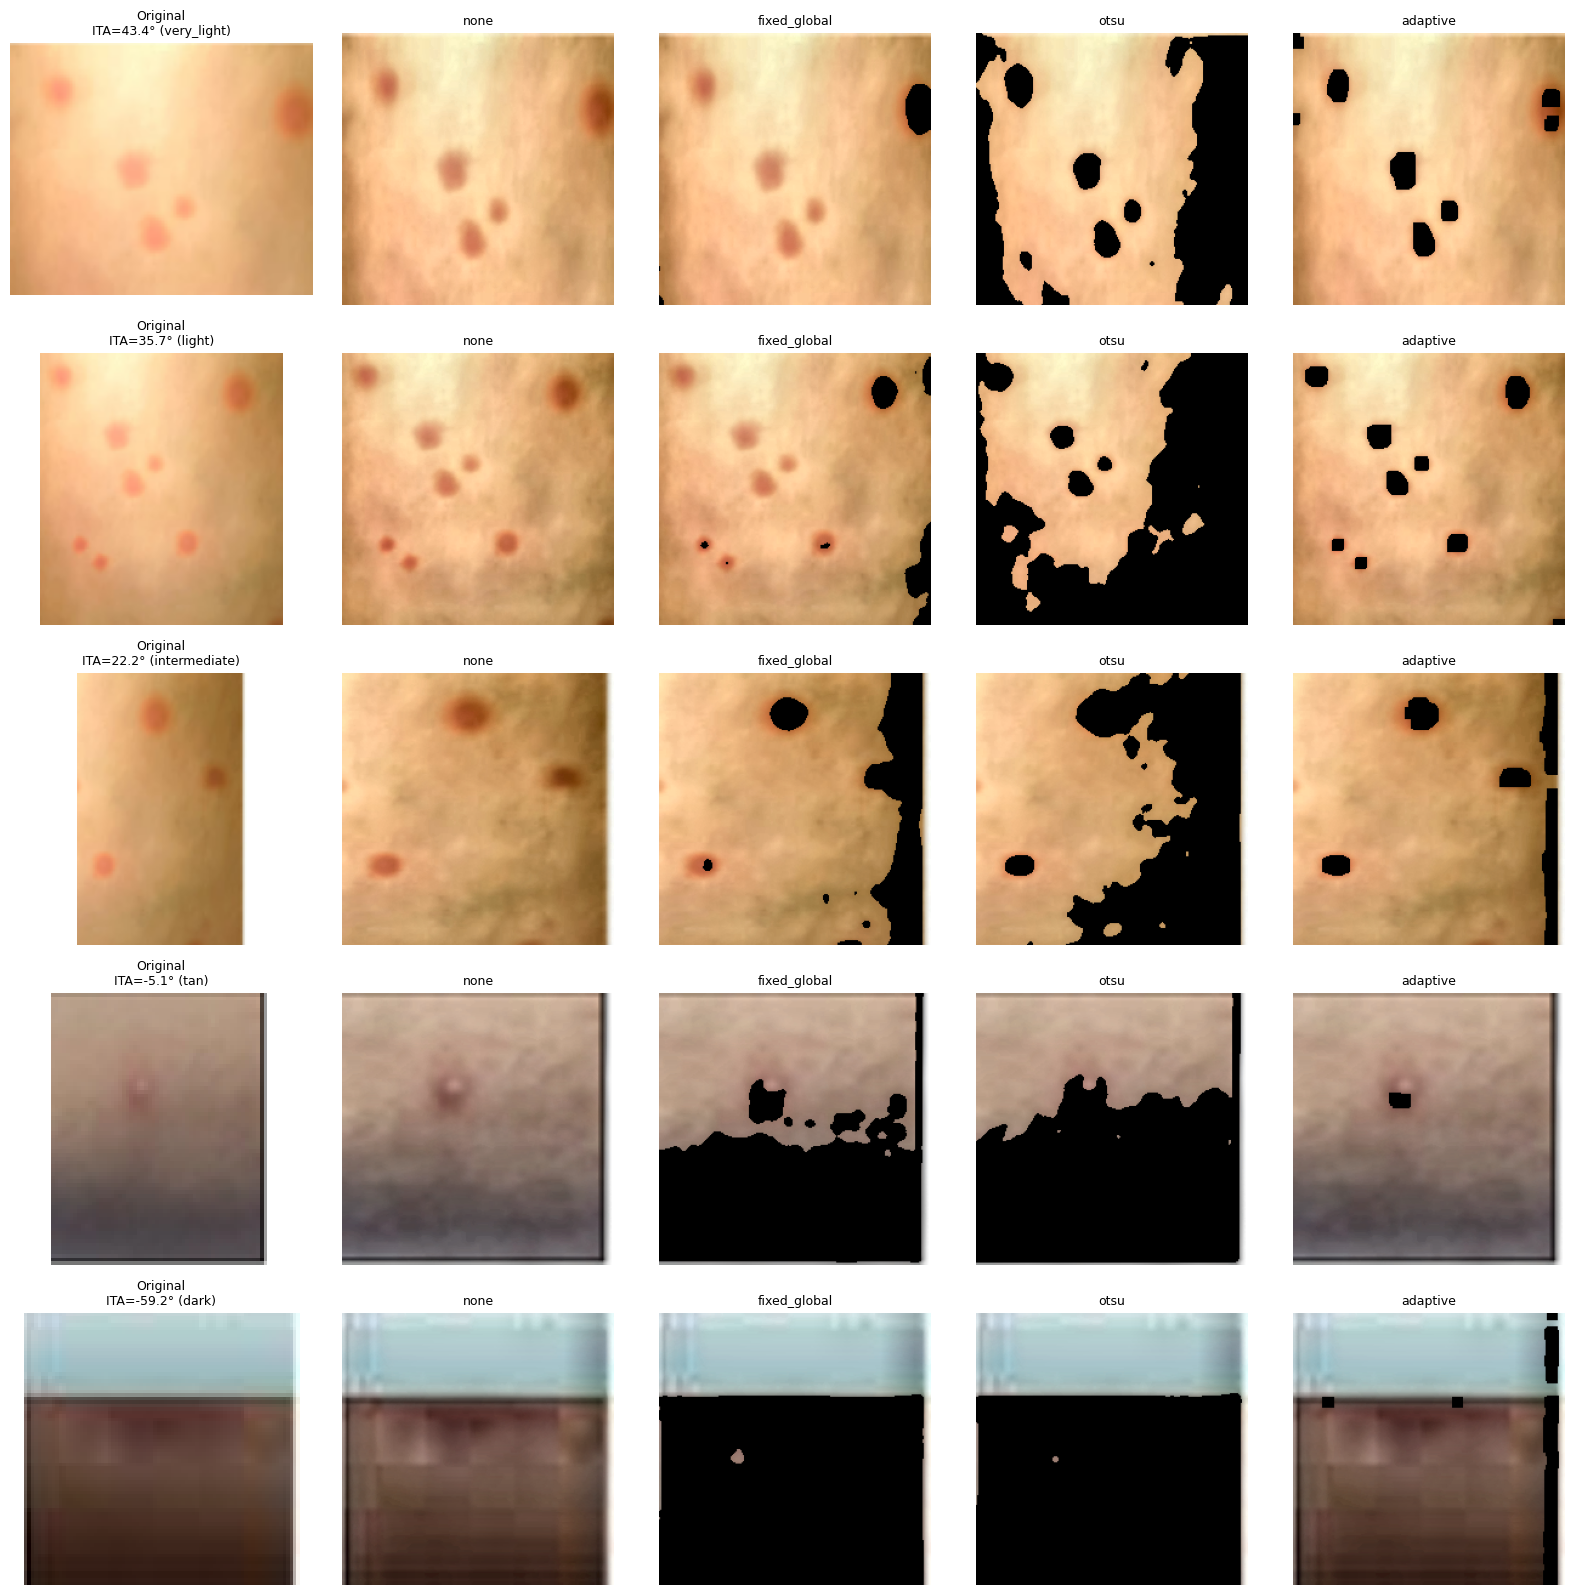

Saved: /kaggle/working/confusion_fixed_global.png


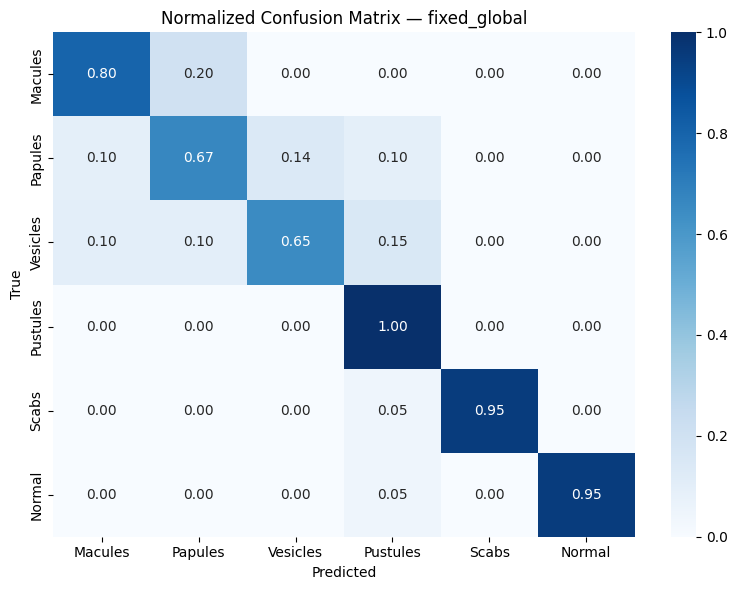

Saved: /kaggle/working/confusion_otsu.png


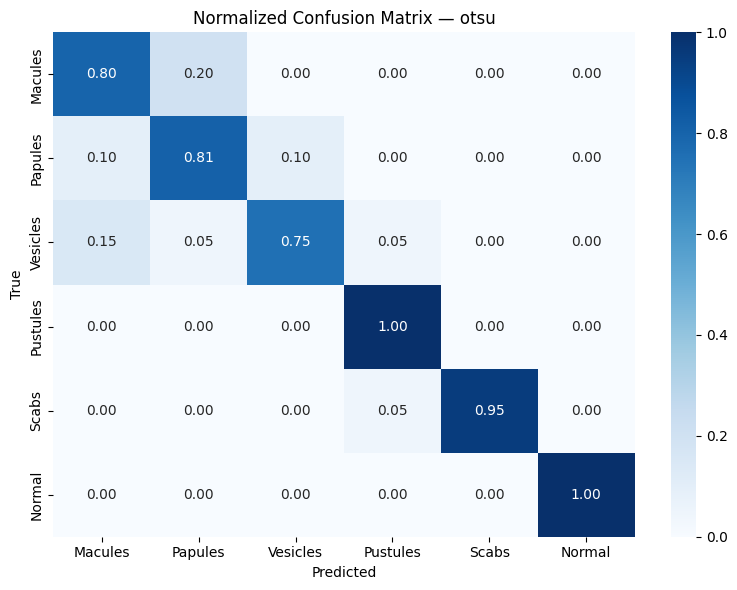

Saved: /kaggle/working/confusion_adaptive.png


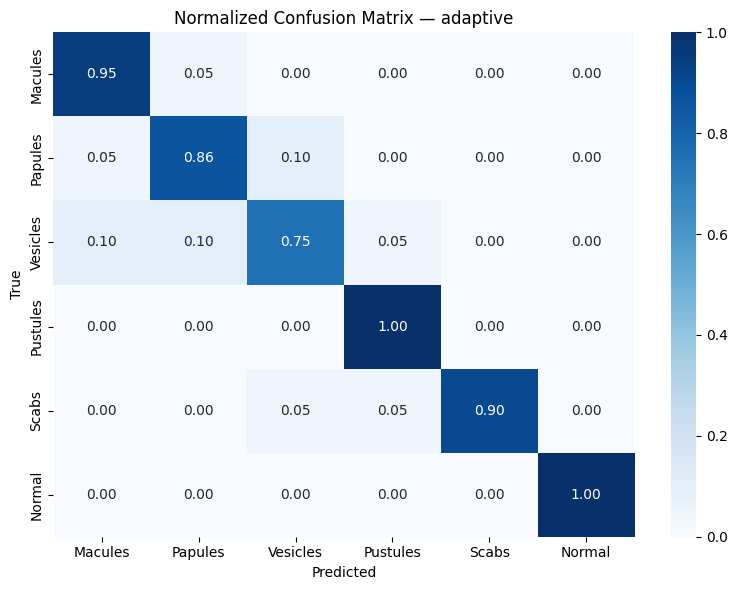

Saved: /kaggle/working/confusion_none.png


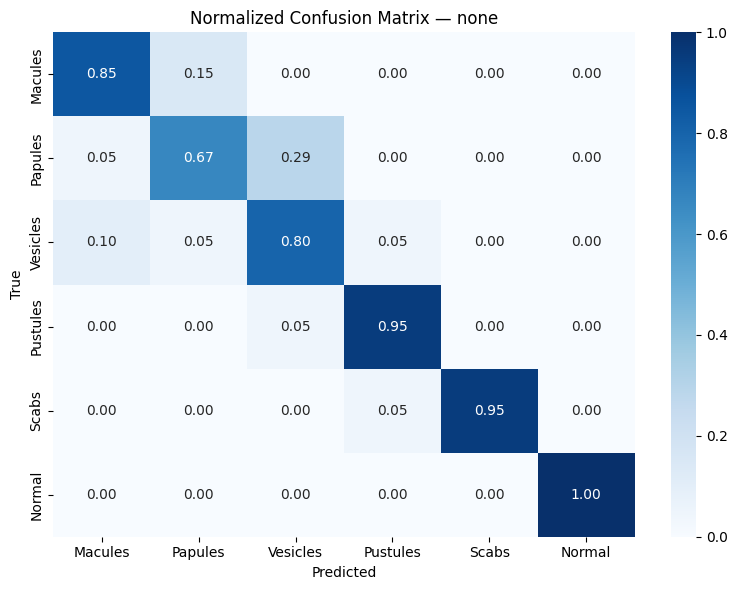


✅ All outputs saved to: /kaggle/working
['stratified_otsu.csv', 'confusion_adaptive.png', 'stratified_adaptive.csv', 'mpoxsevnet_none.keras', 'stratified_none.csv', 'segmentation_comparison.csv', 'mpoxsevnet_adaptive.keras', 'confusion_otsu.png', 'mpoxsevnet_otsu.keras', 'confusion_none.png', 'stratified_fixed_global.csv', 'segmentation_compare.png', 'mpoxsevnet_fixed_global.keras', '.virtual_documents', 'confusion_fixed_global.png']


In [2]:
# ============================================================
# MPoxSevNet — Reviewer Response
# Kaggle version for dataset: dirework/mpox-datasett
# Auto-detects folder structure (1_Macules, 2_Papules, etc.)
# ============================================================

# ---------- Imports ----------
import os, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
from sklearn.model_selection import train_test_split

# ---------- Config ----------
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

IMG_SIZE, BATCH_SIZE, NUM_CLASSES = 224, 32, 6
EPOCHS          = 10    # smoke test — raise to 30 for full
EPOCHS_FINETUNE = 1     # smoke test — raise to 10 for full

CLASS_NAMES = ['Macules', 'Papules', 'Vesicles', 'Pustules', 'Scabs', 'Normal']

# >>>>>>>>>>>>>> AUTO-LOCATE DATA DIR <<<<<<<<<<<<<<
def find_data_dir(root='/kaggle/input'):
    """Search for a folder containing subfolders starting with '1_'."""
    for dirpath, dirnames, _ in os.walk(root):
        for d in dirnames:
            if d.startswith('1_'):
                return dirpath
    return None

DATA_DIR = find_data_dir()
if DATA_DIR is None:
    # Fallback: try likely paths
    for candidate in [
        '/kaggle/input/mpox-datasett/dataset',
        '/kaggle/input/mpox-datasett/mpoxdataset',
        '/kaggle/input/mpox-datasett',
    ]:
        if os.path.isdir(candidate):
            DATA_DIR = candidate
            break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not locate dataset. Please run in a separate cell:\n"
        "import os\n"
        "for dp, dn, fn in os.walk('/kaggle/input'):\n"
        "    print(dp, '->', dn[:5])\n"
        "and paste the output."
    )

print(f"✅ DATA_DIR = {DATA_DIR}")
print("Contents:", sorted(os.listdir(DATA_DIR))[:10])

OUT_DIR = '/kaggle/working'
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# PREPROCESSING & SEGMENTATION
# ============================================================
def preprocess_base(img):
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

def apply_mask(img, mask):
    return cv2.bitwise_and(img, img, mask=mask)

def segment_fixed_global(img, T=125):
    gray = cv2.medianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 5)
    _, mask = cv2.threshold(gray, T, 255, cv2.THRESH_BINARY)
    return apply_mask(img, mask)

def segment_otsu(img):
    gray = cv2.medianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 5)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return apply_mask(img, mask)

def segment_adaptive_local(img, block_size=35, C=5):
    gray = cv2.medianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 5)
    mask = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, block_size, C)
    k = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    return apply_mask(img, mask)

def segment_none(img):
    return img

SEGMENTERS = {
    'fixed_global': segment_fixed_global,
    'otsu':         segment_otsu,
    'adaptive':     segment_adaptive_local,
    'none':         segment_none,
}

# ============================================================
# SKIN TONE (ITA)
# ============================================================
def compute_ita(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    L, _, b = cv2.split(lab)
    L = L.astype(np.float32) * (100.0 / 255.0)
    b = b.astype(np.float32) - 128.0
    skin = L > 20
    if skin.sum() < 50: return None
    Lm, bm = np.median(L[skin]), np.median(b[skin])
    return float(np.degrees(np.arctan((Lm - 50.0) / (bm + 1e-6))))

def ita_group(ita):
    if ita is None: return 'unknown'
    if ita >  41:   return 'very_light'
    if ita >  28:   return 'light'
    if ita >  10:   return 'intermediate'
    if ita > -30:   return 'tan'
    return 'dark'

# ============================================================
# DATA LOADING (flexible folder matching)
# ============================================================
def find_class_folder(data_dir, idx, class_name):
    candidates = glob(os.path.join(data_dir, f'{idx}_*')) + \
                 glob(os.path.join(data_dir, f'{idx}-*')) + \
                 [os.path.join(data_dir, class_name)]
    for c in candidates:
        if os.path.isdir(c): return c
    return None

def load_dataset(data_dir, class_names):
    paths, labels, itas = [], [], []
    for idx, cname in enumerate(class_names, start=1):
        folder = find_class_folder(data_dir, idx, cname)
        if folder is None:
            print(f"[WARN] No folder for class {idx}_{cname}")
            continue
        files = sum([glob(os.path.join(folder, e))
                     for e in ('*.PNG', '*.png', '*.JPG', '*.jpg',
                               '*.JPEG', '*.jpeg')], [])
        print(f"  {os.path.basename(folder)}: {len(files)} images")
        for f in files:
            raw = cv2.imread(f)
            if raw is None: continue
            paths.append(f); labels.append(cname); itas.append(compute_ita(raw))
    df = pd.DataFrame({'path': paths, 'label': labels, 'ita': itas})
    df['skin_group'] = df['ita'].apply(ita_group)
    return df

# ============================================================
# MODEL
# ============================================================
def build_mpoxsevnet():
    base = ResNet50(weights='imagenet', include_top=False,
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    m = models.Model(base.input, out)
    m.compile(optimizer=optimizers.Adam(1e-4),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def unfreeze_last_block(model, name='conv5_block3'):
    for l in model.layers:
        if name in l.name: l.trainable = True
    model.compile(optimizer=optimizers.Adam(1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ============================================================
# PIPELINE
# ============================================================
def make_generators(df_sub, seg_fn, augment=True):
    tr, tmp = train_test_split(df_sub, test_size=0.2,
                               stratify=df_sub['label'], random_state=SEED)
    va, te = train_test_split(tmp, test_size=0.5,
                              stratify=tmp['label'], random_state=SEED)
    aug = ImageDataGenerator(
        rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
        shear_range=0.1, zoom_range=0.1, horizontal_flip=True,
        fill_mode='nearest') if augment else ImageDataGenerator()

    def flow(sub, a):
        return a.flow_from_dataframe(
            sub, x_col='path', y_col='label',
            target_size=(IMG_SIZE, IMG_SIZE),
            classes=CLASS_NAMES,
            class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False,
            preprocessing_function=lambda im: seg_fn(preprocess_base(im)))
    return flow(tr, aug), flow(va, ImageDataGenerator()), flow(te, ImageDataGenerator()), te.reset_index(drop=True)

def evaluate_model(model, gen):
    yp = np.array(model.predict(gen, verbose=0).argmax(1))
    yt = np.array(gen.classes)
    return {'accuracy': accuracy_score(yt, yp),
            'precision': precision_score(yt, yp, average='weighted', zero_division=0),
            'recall': recall_score(yt, yp, average='weighted', zero_division=0),
            'f1': f1_score(yt, yp, average='weighted', zero_division=0),
            'y_true': yt, 'y_pred': yp}

def run_experiment(seg_name, df):
    print(f"\n{'='*60}\nSegmentation: {seg_name}\n{'='*60}")
    tr, va, te, te_df = make_generators(df, SEGMENTERS[seg_name])
    model = build_mpoxsevnet()
    cb = [callbacks.EarlyStopping(patience=8, restore_best_weights=True),
          callbacks.ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7)]
    model.fit(tr, validation_data=va, epochs=EPOCHS, callbacks=cb, verbose=1)
    model = unfreeze_last_block(model)
    model.fit(tr, validation_data=va, epochs=EPOCHS_FINETUNE, callbacks=cb, verbose=1)
    m = evaluate_model(model, te)
    m['test_df'] = te_df; m['model'] = model
    model.save(os.path.join(OUT_DIR, f'mpoxsevnet_{seg_name}.keras'))
    return m

# ============================================================
# STRATIFIED EVALUATION
# ============================================================
def stratified_evaluation(metrics):
    tdf = metrics['test_df']; yt = metrics['y_true']; yp = metrics['y_pred']
    rows = []
    for g in ['very_light', 'light', 'intermediate', 'tan', 'dark']:
        mask = tdf['skin_group'].values == g
        n = int(mask.sum())
        rows.append({'group': g, 'n': n,
                     'accuracy': accuracy_score(yt[mask], yp[mask]) if n >= 5 else None,
                     'f1': f1_score(yt[mask], yp[mask], average='weighted',
                                    zero_division=0) if n >= 5 else None})
    return pd.DataFrame(rows)

# ============================================================
# VISUALIZATION
# ============================================================
def visualize_segmentation(sample_paths, save=None):
    methods = ['none', 'fixed_global', 'otsu', 'adaptive']
    n = len(sample_paths)
    fig, ax = plt.subplots(n, len(methods) + 1,
                           figsize=(3.2 * (len(methods) + 1), 3.2 * n))
    ax = np.atleast_2d(ax)
    for i, p in enumerate(sample_paths):
        raw = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        ita = compute_ita(cv2.cvtColor(raw, cv2.COLOR_RGB2BGR))
        ax[i, 0].imshow(raw)
        ax[i, 0].set_title(f"Original\nITA={ita:.1f}° ({ita_group(ita)})", fontsize=9)
        ax[i, 0].axis('off')
        for j, m in enumerate(methods, 1):
            seg = SEGMENTERS[m](preprocess_base(cv2.cvtColor(raw, cv2.COLOR_RGB2BGR)))
            ax[i, j].imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB))
            ax[i, j].set_title(m, fontsize=9); ax[i, j].axis('off')
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight'); print(f"Saved: {save}")
    plt.show()

def plot_confusion(metrics, name, save=None):
    cm = confusion_matrix(metrics['y_true'], metrics['y_pred'], normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Normalized Confusion Matrix — {name}')
    plt.ylabel('True'); plt.xlabel('Predicted'); plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight'); print(f"Saved: {save}")
    plt.show()

# ============================================================
# MAIN
# ============================================================
def main():
    assert os.path.isdir(DATA_DIR), f"DATA_DIR not found: {DATA_DIR}"
    print(f"Loading dataset from: {DATA_DIR}\n")
    df = load_dataset(DATA_DIR, CLASS_NAMES)
    print(f"\nTotal images: {len(df)}")
    print("\nClass distribution:\n", df['label'].value_counts().sort_index())
    print("\nSkin-tone distribution:\n", df['skin_group'].value_counts())

    results = {}
    for name in ['fixed_global', 'otsu', 'adaptive', 'none']:
        results[name] = run_experiment(name, df)

    comparison = pd.DataFrame({
        n: {'Accuracy':  f"{m['accuracy']*100:.2f}%",
            'Precision': f"{m['precision']*100:.2f}%",
            'Recall':    f"{m['recall']*100:.2f}%",
            'F1-score':  f"{m['f1']*100:.2f}%"}
        for n, m in results.items()}).T
    print("\n=== Segmentation Comparison ==="); print(comparison)
    comparison.to_csv(os.path.join(OUT_DIR, 'segmentation_comparison.csv'))

    print("\n=== Skin-Tone Stratified Results ===")
    for n, m in results.items():
        s = stratified_evaluation(m)
        s['accuracy'] = s['accuracy'].apply(lambda v: f"{v*100:.2f}%" if v is not None else "N/A")
        s['f1']       = s['f1'].apply(lambda v: f"{v*100:.2f}%" if v is not None else "N/A")
        print(f"\n--- {n} ---"); print(s.to_string(index=False))
        s.to_csv(os.path.join(OUT_DIR, f'stratified_{n}.csv'), index=False)

    samples = []
    for g in ['very_light', 'light', 'intermediate', 'tan', 'dark']:
        sub = df[df['skin_group'] == g]
        if len(sub) > 0: samples.append(sub.iloc[0]['path'])
    if samples:
        visualize_segmentation(samples,
            save=os.path.join(OUT_DIR, 'segmentation_compare.png'))

    for n, m in results.items():
        plot_confusion(m, n, save=os.path.join(OUT_DIR, f'confusion_{n}.png'))

    print(f"\n✅ All outputs saved to: {OUT_DIR}")
    print(os.listdir(OUT_DIR))

main()